In [1]:
# Core Libraries
import pandas as pd
import numpy as np

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Save Model
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
np.random.seed(42)

data_size = 500

vehicle_count = np.random.randint(0, 5, data_size)
human_count = np.random.randint(0, 3, data_size)
avg_conf = np.random.uniform(0.4, 0.95, data_size)
overlap_count = np.random.randint(0, 3, data_size)
speed = np.random.randint(0, 20, data_size)

# Crash logic for generating labels
labels = []

for i in range(data_size):
    if (overlap_count[i] > 0 and vehicle_count[i] >= 1) or (speed[i] > 12 and vehicle_count[i] > 1):
        labels.append(1)  # Crash
    else:
        labels.append(0)  # No Crash

# Create DataFrame
df = pd.DataFrame({
    "vehicle_count": vehicle_count,
    "human_count": human_count,
    "avg_conf": avg_conf,
    "overlap_count": overlap_count,
    "speed": speed,
    "label": labels
})

df.head()


,vehicle_count,human_count,avg_conf,overlap_count,speed,label
0,3,1,0.909547,0,14,1
1,4,0,0.796878,0,9,0
2,2,1,0.426452,2,9,1
3,4,0,0.829833,0,7,0
4,4,2,0.855367,2,15,1


In [3]:
X = df.drop("label", axis=1)
y = df["label"]


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [5]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



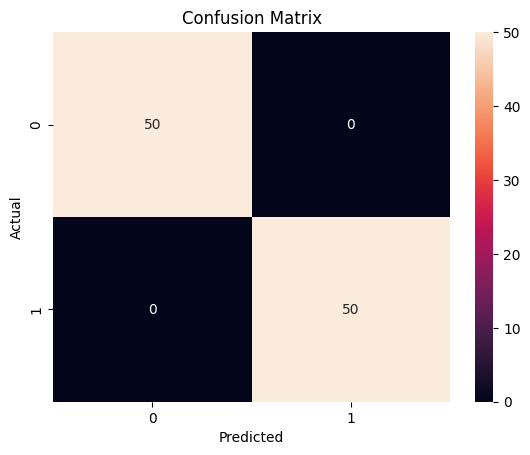

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


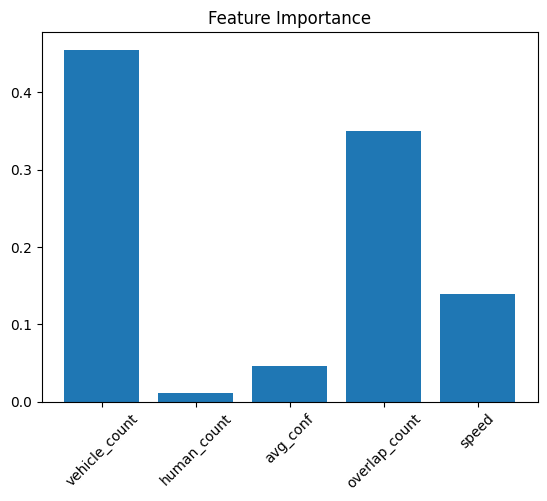

In [8]:
importances = model.feature_importances_
feature_names = X.columns

plt.figure()
plt.bar(feature_names, importances)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()


In [9]:
joblib.dump(model, "crash_prediction_model.pkl")
print("Model saved successfully!")


Model saved successfully!


In [10]:
sample = [[2, 1, 0.85, 1, 15]]  # vehicle, human, conf, overlap, speed
prediction = model.predict(sample)

if prediction[0] == 1:
    print("🚨 Crash Predicted")
else:
    print("✅ No Crash")


🚨 Crash Predicted


C:\Users\shabh\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
